# Data exploration: historical matches

10 complete seasons (2016-17 to 2025-26) of the top 5 European leagues, from football-data.co.uk.
Goal: understand the data before building features and models, and decide what needs cleaning.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from football_agent.predictor.data import RAW_DATA_DIR, SEASONS, load_matches

# The notebook runs from notebooks/, while the data lives at the repository root.
matches = load_matches(Path("..") / RAW_DATA_DIR, SEASONS)
matches.shape

(17937, 18)

In [2]:
matches.head()

,date,home_team,away_team,home_goals,away_goals,result,home_shots,away_shots,home_shots_on_target,away_shots_on_target,pinnacle_odds_home,pinnacle_odds_draw,pinnacle_odds_away,average_odds_home,average_odds_draw,average_odds_away,competition,season
0,2016-08-12,Bastia,Paris SG,0,1,A,10.0,9.0,0.0,6.0,12.13,5.29,1.34,NaN,NaN,NaN,FL1,2016
1,2016-08-12,Monaco,Guingamp,2,2,D,18.0,9.0,4.0,5.0,1.71,3.75,5.87,NaN,NaN,NaN,FL1,2016
2,2016-08-13,Burnley,Swansea,0,1,A,10.0,17.0,3.0,9.0,2.79,3.16,2.89,NaN,NaN,NaN,PL,2016
3,2016-08-13,Crystal Palace,West Brom,0,1,A,14.0,13.0,4.0,3.0,2.25,3.15,3.86,NaN,NaN,NaN,PL,2016
4,2016-08-13,Everton,Tottenham,1,1,D,12.0,13.0,6.0,4.0,3.64,3.54,2.16,NaN,NaN,NaN,PL,2016


## 1. Data quality

In [3]:
matches.isna().sum()[lambda counts: counts > 0]

home_shots                 2
away_shots                 2
home_shots_on_target       2
away_shots_on_target       2
pinnacle_odds_home       856
pinnacle_odds_draw       856
pinnacle_odds_away       856
average_odds_home       5478
average_odds_draw       5478
average_odds_away       5478
dtype: int64

In [4]:
result_from_goals = np.select(
    [matches["home_goals"] > matches["away_goals"], matches["home_goals"] < matches["away_goals"]],
    ["H", "A"],
    "D",
)
print("results inconsistent with goals:", (result_from_goals != matches["result"]).sum())
print("duplicated matches:", matches.duplicated(["date", "home_team", "away_team"]).sum())

results inconsistent with goals: 0
duplicated matches: 0


The two matches without shot statistics:

In [5]:
matches[matches["home_shots"].isna()][
    ["date", "competition", "home_team", "away_team", "home_goals", "away_goals"]
]

,date,competition,home_team,away_team,home_goals,away_goals
1540,2017-04-16,FL1,Bastia,Lyon,0,3
15147,2024-12-14,BL1,Union Berlin,Bochum,0,2


Both are **awarded results**, not played scores:

- **Bastia - Lyon (2017-04-16)**: abandoned at half-time after crowd trouble, awarded 0-3 to Lyon.
- **Union Berlin - Bochum (2024-12-14)**: the Bochum goalkeeper was hit by a lighter; the 1-1 was turned into a 0-2 win for Bochum.

They count in the standings, so they stay in the data. Their shots are missing (NaN), which rolling averages will simply skip.

In [6]:
odds_coverage = matches.groupby("season")[["pinnacle_odds_home", "average_odds_home"]].agg(
    lambda odds: round(100 * odds.notna().mean())
)
odds_coverage.columns = ["pinnacle_closing_%", "average_closing_%"]
odds_coverage

,pinnacle_closing_%,average_closing_%
season,,
2016,100,0
2017,100,0
2018,100,0
2019,100,100
2020,100,100
2021,100,100
2022,100,100
2023,100,100
2024,100,100


Every match has at least one closing price: Pinnacle is complete until 2024-25 but covers about half of 2025-26;
the multi-bookmaker average only exists from 2019-20.

## 2. Outcomes and home advantage

In [7]:
outcomes = (
    pd.crosstab(matches["competition"], matches["result"], normalize="index")[["H", "D", "A"]] * 100
)
outcomes.round(1)

result,H,D,A
competition,,,
BL1,44.2,24.8,30.9
FL1,43.9,25.2,30.8
PD,45.5,26.2,28.3
PL,44.6,23.2,32.1
SA,41.9,25.5,32.5


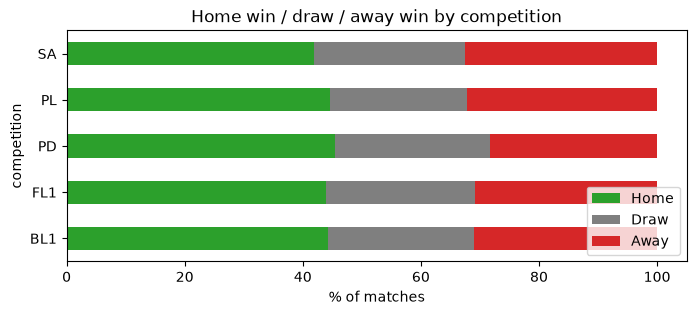

In [8]:
outcomes.plot.barh(stacked=True, color=["tab:green", "tab:gray", "tab:red"], figsize=(8, 3))
plt.xlabel("% of matches")
plt.title("Home win / draw / away win by competition")
plt.legend(["Home", "Draw", "Away"], loc="lower right")
plt.show()

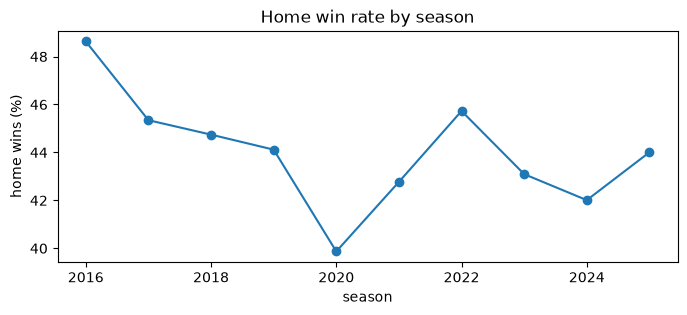

In [9]:
home_win_rate = matches.groupby("season")["result"].apply(
    lambda result: (result == "H").mean() * 100
)
home_win_rate.plot(marker="o", figsize=(8, 3))
plt.ylabel("home wins (%)")
plt.title("Home win rate by season")
plt.show()

- About **44% home wins, 25% draws, 31% away wins**, and the split is similar in every league (Serie A has the smallest home advantage).
- **2020-21 dips to 40%**: matches were played **behind closed doors** (Covid). Part of the home advantage comes from the crowd.
- A model that always answers 44 / 25 / 31 is the **naive baseline** to beat.

## 3. Goals

In [10]:
total_goals = matches["home_goals"] + matches["away_goals"]
print("goals per match:", round(total_goals.mean(), 2))
total_goals.groupby(matches["competition"]).mean().round(2)

goals per match: 2.79


competition
BL1    3.10
FL1    2.73
PD     2.62
PL     2.84
SA     2.74
dtype: float64

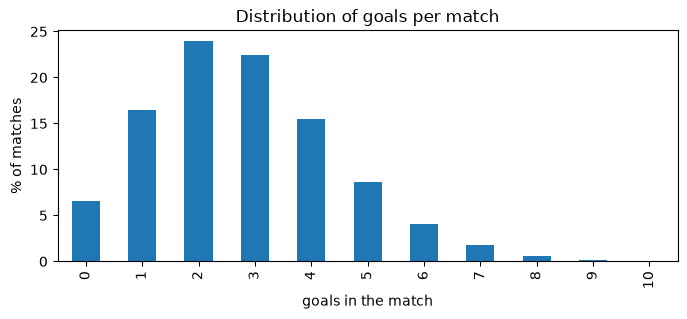

In [11]:
total_goals.value_counts(normalize=True).sort_index().mul(100).plot.bar(figsize=(8, 3))
plt.xlabel("goals in the match")
plt.ylabel("% of matches")
plt.title("Distribution of goals per match")
plt.show()

2.8 goals per match on average; the Bundesliga is the highest-scoring league (3.1). Most matches end with 1 to 4 goals.

## 4. How good are the bookmakers?

Implied probability = 1 / odds, divided by the sum over the three outcomes to remove the bookmaker margin.
If the market is well calibrated, home teams given a 60% chance should win about 60% of the time.

In [12]:
closing_odds = pd.DataFrame(
    {
        outcome: matches[f"average_odds_{outcome}"].fillna(matches[f"pinnacle_odds_{outcome}"])
        for outcome in ["home", "draw", "away"]
    }
)
implied = 1 / closing_odds
print(f"average bookmaker margin: {(implied.sum(axis=1).mean() - 1) * 100:.1f}%")
market_home_probability = implied["home"] / implied.sum(axis=1)

calibration = (
    pd.DataFrame({"market": market_home_probability, "home_won": matches["result"] == "H"})
    .groupby(
        pd.cut(market_home_probability, [0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1]), observed=True
    )
    .agg(matches=("market", "size"), market=("market", "mean"), observed=("home_won", "mean"))
)
calibration

average bookmaker margin: 4.0%


,matches,market,observed
"(0.0, 0.2]",1947,0.142879,0.136107
"(0.2, 0.3]",2437,0.254324,0.237177
"(0.3, 0.4]",3528,0.351797,0.339569
"(0.4, 0.5]",3603,0.448179,0.447682
"(0.5, 0.6]",2676,0.548105,0.564649
"(0.6, 0.7]",1871,0.647634,0.676644
"(0.7, 0.8]",1257,0.746246,0.752586
"(0.8, 1.0]",616,0.844652,0.847403


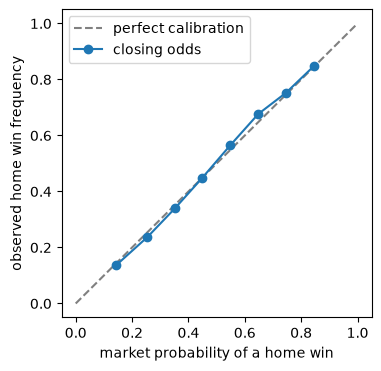

In [13]:
plt.figure(figsize=(4, 4))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")
plt.plot(calibration["market"], calibration["observed"], marker="o", label="closing odds")
plt.xlabel("market probability of a home win")
plt.ylabel("observed home win frequency")
plt.legend()
plt.show()

The market is **very well calibrated**: in every bucket, the observed frequency is within about 3 points of the market probability.
That is why the closing odds are a hard benchmark: the realistic goal for our model is to get close to it, not to beat it.

## 5. Conclusions for the next tasks

- **Data quality is good**: no duplicates, results consistent with goals, plausible odds. Only 2 awarded matches lack shots: kept as they are.
- **No cleaning step is needed** beyond what `load_matches` already does.
- **Baselines**: naive frequencies (44 / 25 / 31) and closing odds (complete coverage when combining Pinnacle and the average).
- **Home advantage matters** and varies over time (2020-21), so features should keep home and away teams separate.
- **Teams have very different histories** (from 34 to 380 matches): promoted teams start with little or no history, so features will be NaN at first.